In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from cesnet_datazoo.datasets import CESNET_TLS22
from cesnet_datazoo.config import DatasetConfig, AppSelection

dataset = CESNET_TLS22("data/CESNET-TLS22/", size="XS")

dataset_config = DatasetConfig(
    dataset=dataset,
    apps_selection=AppSelection.ALL_KNOWN, 
    return_other_fields=True 
)

dataset.set_dataset_config_and_initialize(dataset_config)

df = dataset.get_train_df()
print(f"total loaded flows: {len(df)}")

In [ ]:
display(df.head())

df.info()


print("Colls in data: ")
print(list(df.columns))

In [5]:
import pandas as pd

servicemap_df = pd.read_csv('data/CESNET-TLS22/XS/servicemap.csv')

app_dict = servicemap_df['Service'].to_dict()

df['APP_NAME'] = df['APP'].map(app_dict)

tiktok_stats = df[df['APP_NAME'].str.contains('TikTok', na=False, case=False)]
print(f"\nFound {len(tiktok_stats)} TikTok records")


Found 116963 TikTok records


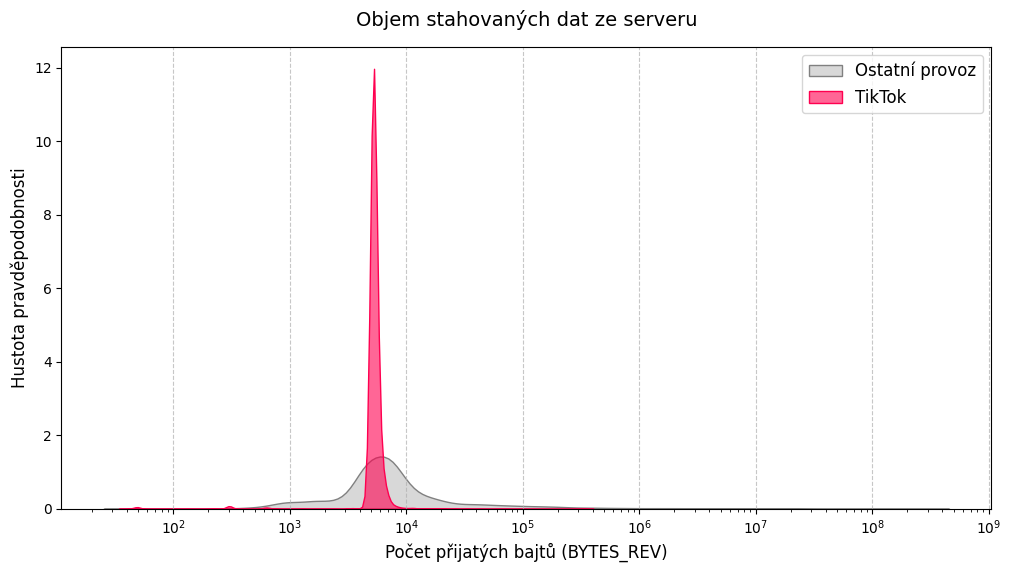

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tiktok_df = df[df['APP_NAME'] == 'TikTok'].sample(10000, random_state=42)
other_df = df[df['APP_NAME'] != 'TikTok'].sample(10000, random_state=42)

plt.figure(figsize=(12, 6))

sns.kdeplot(other_df['BYTES_REV'] + 1, label='Ostatní provoz', 
            fill=True, alpha=0.3, color='gray', log_scale=True)

sns.kdeplot(tiktok_df['BYTES_REV'] + 1, label='TikTok', 
            fill=True, alpha=0.6, color='#ff0050', log_scale=True)

plt.title('Objem stahovaných dat ze serveru', fontsize=14, pad=15)
plt.xlabel('Počet přijatých bajtů (BYTES_REV)', fontsize=12)
plt.ylabel('Hustota pravděpodobnosti', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Random Forest Training...


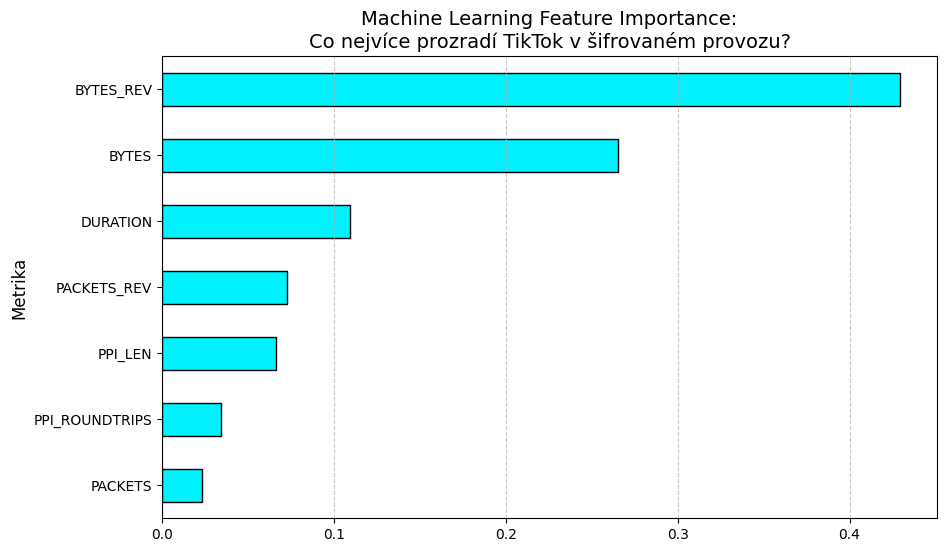

In [29]:
from sklearn.ensemble import RandomForestClassifier

ml_data = pd.concat([tiktok_df, other_df])


features = ['BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'DURATION', 'PPI_LEN', 'PPI_ROUNDTRIPS']

X = ml_data[features].fillna(0)
y = (ml_data['APP_NAME'] == 'TikTok').astype(int) 


print("Random Forest Training...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

# Vykreslení
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#00f2fe', edgecolor='black')

plt.title('Machine Learning Feature Importance:\nCo nejvíce prozradí TikTok v šifrovaném provozu?', fontsize=14)
plt.ylabel('Metrika', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('tiktok_most_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plot_sample_tt = df[df['APP_NAME'] == 'TikTok'].sample(15000, random_state=42).copy()
plot_sample_oth = df[df['APP_NAME'] != 'TikTok'].sample(15000, random_state=42).copy()

plot_sample_tt['Typ'] = 'TikTok'
plot_sample_oth['Typ'] = 'Ostatní'

viz_df = pd.concat([plot_sample_tt, plot_sample_oth])

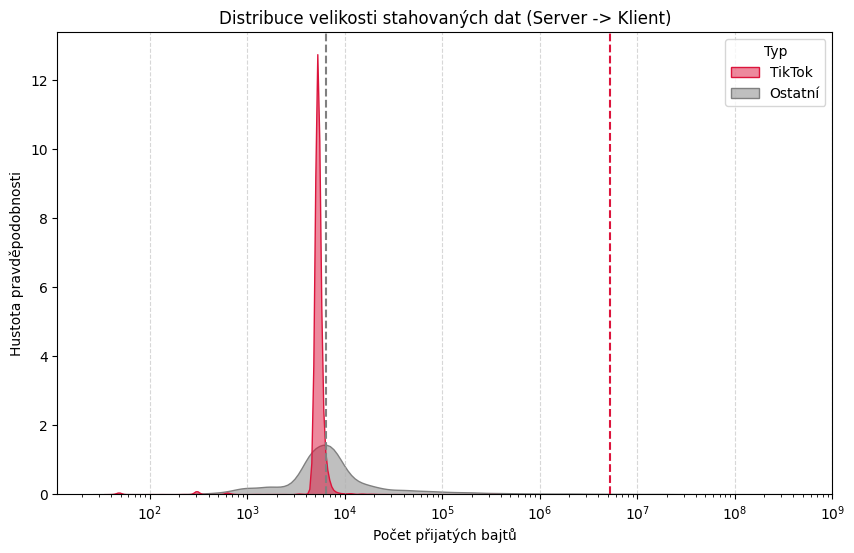

In [31]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=viz_df, x='BYTES_REV', hue='Typ', fill=True, alpha=0.5, 
            palette={'TikTok': 'crimson', 'Ostatní': 'gray'}, 
            log_scale=True, common_norm=False)

plt.title('Distribuce velikosti stahovaných dat (Server -> Klient)')
plt.xlabel('Počet přijatých bajtů')
plt.ylabel('Hustota pravděpodobnosti')
plt.grid(axis='x', linestyle='--', alpha=0.5)

median_tt = viz_df[viz_df['Typ'] == 'TikTok']['BYTES_REV'].median() / 1024 
median_oth = viz_df[viz_df['Typ'] == 'Ostatní']['BYTES_REV'].median() / 1024 
plt.axvline(median_tt * 1024 * 1024, color='crimson', linestyle='--')
plt.axvline(median_oth * 1024, color='gray', linestyle='--')


plt.savefig('tiktok_dwnload.png', dpi=300, bbox_inches='tight')

plt.show()

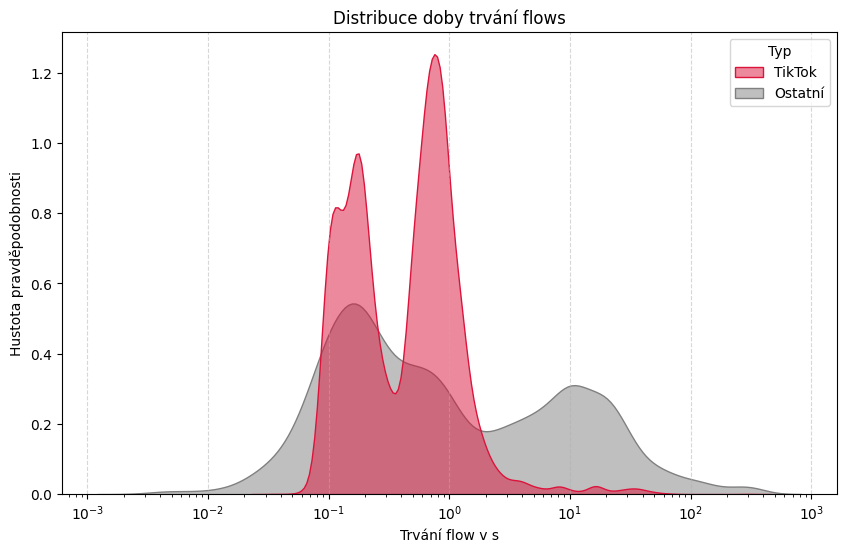

In [33]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=viz_df, x='DURATION', hue='Typ', fill=True, alpha=0.5, 
            palette={'TikTok': 'crimson', 'Ostatní': 'gray'}, 
            log_scale=True, common_norm=False)

plt.title('Distribuce doby trvání flows')
plt.xlabel('Trvání flow v s')
plt.ylabel('Hustota pravděpodobnosti')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.savefig('tiktok_flows.png', dpi=300, bbox_inches='tight')

plt.show()

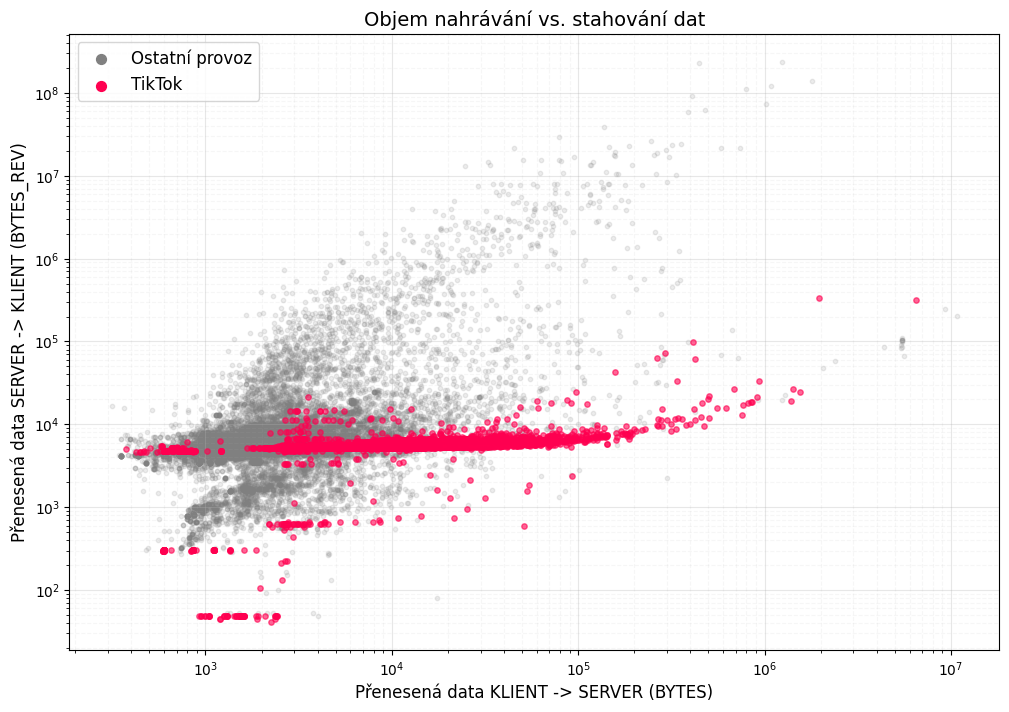

In [35]:
plt.figure(figsize=(12, 8))

plt.scatter(
    plot_sample_oth['BYTES'] + 1, 
    plot_sample_oth['BYTES_REV'] + 1, 
    s=10, color='gray', alpha=0.15, label='Ostatní provoz', zorder=1
)

plt.scatter(
    plot_sample_tt['BYTES'] + 1, 
    plot_sample_tt['BYTES_REV'] + 1, 
    s=15, color='#ff0050', alpha=0.6, label='TikTok', zorder=2
)

plt.xscale('log')
plt.yscale('log')

plt.title('Objem nahrávání vs. stahování dat', fontsize=14)
plt.xlabel('Přenesená data KLIENT -> SERVER (BYTES)', fontsize=12)
plt.ylabel('Přenesená data SERVER -> KLIENT (BYTES_REV)', fontsize=12)

legend = plt.legend(loc='upper left', fontsize=12)
for handle in legend.legend_handles:
    handle.set_sizes([50])
    handle.set_alpha(1)

plt.grid(which="major", linestyle='-', alpha=0.3)
plt.grid(which="minor", linestyle='--', alpha=0.1)

plt.savefig('tiktok_scatter_plot.png', dpi=300, bbox_inches='tight')

plt.show()

In [37]:
category_dict = dict(zip(servicemap_df['Service'], servicemap_df['Service Category']))


df['CATEGORY'] = df['APP_NAME'].map(category_dict)

tt_sample = df[df['APP_NAME'] == 'TikTok'].sample(15000, random_state=42).copy()
tt_sample['Třída'] = 'TikTok'

media_sample = df[(df['CATEGORY'].str.contains('Media', case=False, na=False)) & (df['APP_NAME'] != 'TikTok')].sample(15000, random_state=42).copy()
media_sample['Třída'] = 'Ostatní Media Streaming'

social_sample = df[(df['CATEGORY'].str.contains('Social', case=False, na=False)) & (df['APP_NAME'] != 'TikTok')].sample(15000, random_state=42).copy()
social_sample['Třída'] = 'Ostatní Social Media'

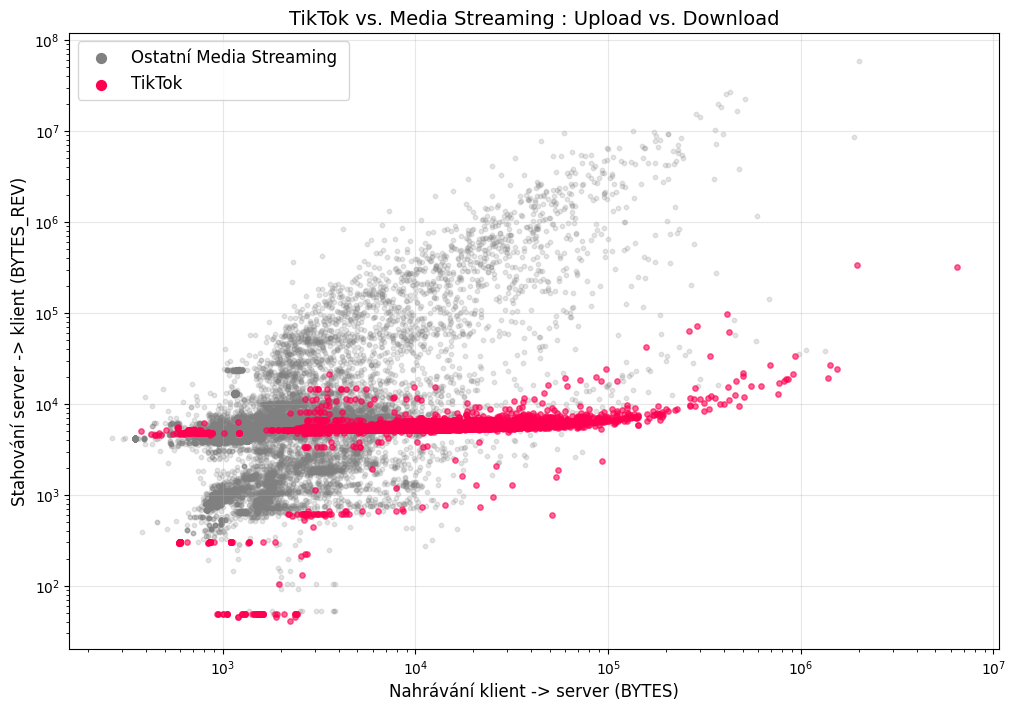

In [38]:
plt.figure(figsize=(12, 8))

plt.scatter(
    media_sample['BYTES'] + 1, 
    media_sample['BYTES_REV'] + 1, 
    s=10, color='gray', alpha=0.2, label='Ostatní Media Streaming ', zorder=1
)

plt.scatter(
    tt_sample['BYTES'] + 1, 
    tt_sample['BYTES_REV'] + 1, 
    s=15, color='#ff0050', alpha=0.6, label='TikTok', zorder=2
)

plt.xscale('log')
plt.yscale('log')

plt.title('TikTok vs. Media Streaming : Upload vs. Download', fontsize=14)
plt.xlabel('Nahrávání klient -> server (BYTES)', fontsize=12)
plt.ylabel('Stahování server -> klient (BYTES_REV)', fontsize=12)

legend = plt.legend(loc='upper left', fontsize=12)
for handle in legend.legend_handles:
    handle.set_sizes([50])
    handle.set_alpha(1)

plt.grid(which="major", linestyle='-', alpha=0.3)

plt.savefig('tiktok_vs_media_streaming.png', dpi=300, bbox_inches='tight')
plt.show()

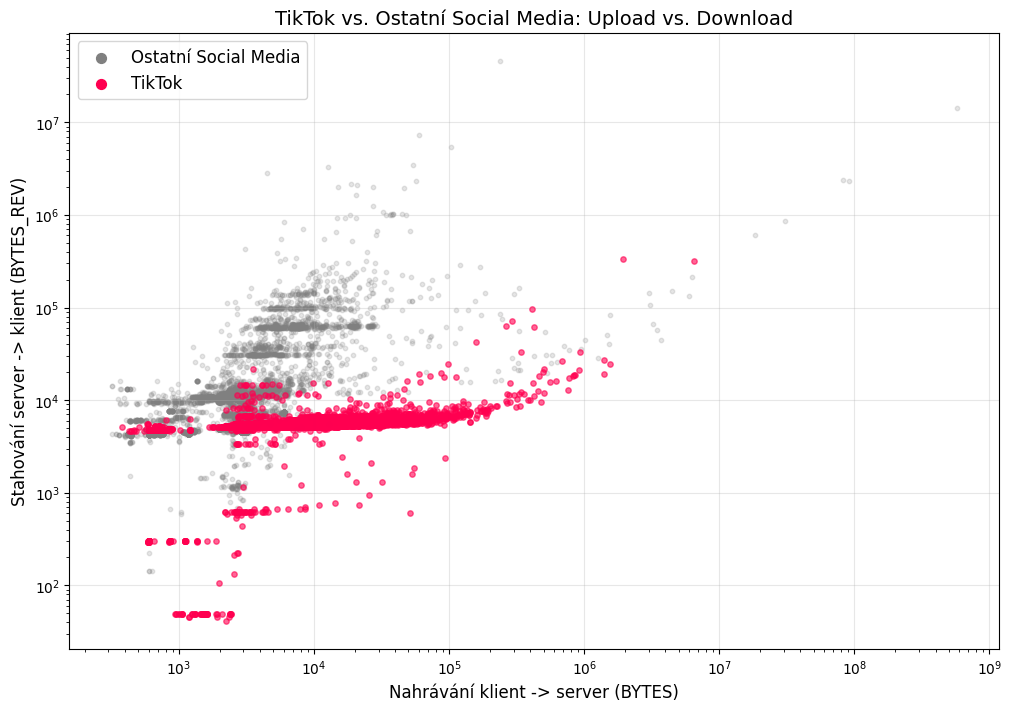

In [40]:
plt.figure(figsize=(12, 8))

plt.scatter(
    social_sample['BYTES'] + 1, 
    social_sample['BYTES_REV'] + 1, 
    s=10, color='gray', alpha=0.2, label='Ostatní Social Media', zorder=1
)

plt.scatter(
    tt_sample['BYTES'] + 1, 
    tt_sample['BYTES_REV'] + 1, 
    s=15, color='#ff0050', alpha=0.6, label='TikTok', zorder=2
)

plt.xscale('log')
plt.yscale('log')

plt.title('TikTok vs. Ostatní Social Media: Upload vs. Download', fontsize=14)
plt.xlabel('Nahrávání klient -> server (BYTES)', fontsize=12)
plt.ylabel('Stahování server -> klient (BYTES_REV)', fontsize=12)

legend = plt.legend(loc='upper left', fontsize=12)
for handle in legend.legend_handles:
    handle.set_sizes([50])
    handle.set_alpha(1)

plt.grid(which="major", linestyle='-', alpha=0.3)

plt.savefig('tiktok_vs_social_media.png', dpi=300, bbox_inches='tight')
plt.show()